# 文件: chart_24_1.py

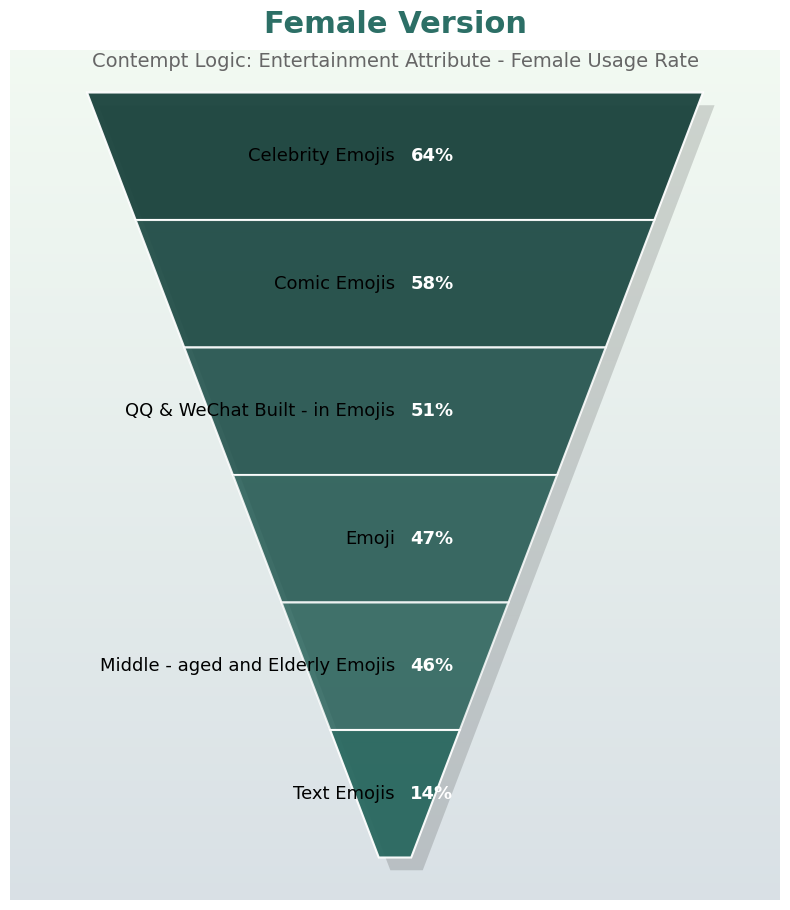

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# Labels and data
labels = [
    "Celebrity Emojis", "Comic Emojis", "QQ & WeChat Built - in Emojis",
    "Emoji", "Middle - aged and Elderly Emojis", "Text Emojis"
]
values = [64, 58, 51, 47, 46, 14]

# Generate gradient color series
def get_gradient_colors(base_color, num_layers, lightness_range=(0.6, 1.0)):
    """Generate gradient colors from dark to light"""
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.colors as mcolors

    # Convert hex color to RGB
    rgb = mcolors.hex2color(base_color)

    # Create gradient color mapping
    cmap = LinearSegmentedColormap.from_list(
        f'custom_{base_color}',
        [(rgb[0]*lightness_range[0], rgb[1]*lightness_range[0], rgb[2]*lightness_range[0]),
         (rgb[0]*lightness_range[1], rgb[1]*lightness_range[1], rgb[2]*lightness_range[1])]
    )

    return [cmap(i/num_layers) for i in range(num_layers)]

# Use green color series as the base
base_color = '#2c6f66'
colors = get_gradient_colors(base_color, len(labels))

# Graph parameters
num_layers = len(labels)
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Coordinates of the bottom vertex
bottom_x = 0.5
bottom_y = 0.05

# Top width (the upper side of the whole inverted triangle)
top_left = (0.1, 0.95)
top_right = (0.9, 0.95)

# Height of each layer (evenly divided)
layer_height = (top_left[1] - bottom_y) / num_layers

# Draw the background gradient
gradient_bg = np.zeros((100, 100, 3))
for i in range(100):
    for j in range(100):
        y_norm = i / 100
        # Background color from light green to lighter green
        gradient_bg[i, j] = [0.95 - y_norm*0.1, 0.98 - y_norm*0.1, 0.95 - y_norm*0.05]
ax.imshow(gradient_bg, extent=[0, 1, 0, 1], aspect='auto', zorder=0)

# Add shadow effect
shadow_offset = 0.015
for i in range(num_layers):
    # Top y and bottom y
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # Calculate the x - coordinates of the left and right boundaries of the triangle at the corresponding height
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # Construct the shadow shape
    shadow_points = [
        (x_left_top + shadow_offset, y_top - shadow_offset),
        (x_right_top + shadow_offset, y_top - shadow_offset),
        (x_right_bottom + shadow_offset, y_bottom - shadow_offset),
        (x_left_bottom + shadow_offset, y_bottom - shadow_offset)
    ]
    shadow = Polygon(shadow_points, closed=True, facecolor='black', alpha=0.15, zorder=i+1)
    ax.add_patch(shadow)

# Draw the main chart
for i in range(num_layers):
    # Top y and bottom y
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # Calculate the x - coordinates of the left and right boundaries of the triangle at the corresponding height
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # Construct the trapezoid/triangular strip shape
    points = [
        (x_left_top, y_top),
        (x_right_top, y_top),
        (x_right_bottom, y_bottom),
        (x_left_bottom, y_bottom)
    ]

    # Add a slight transparency change to make the bottom more obvious
    alpha = 0.95 - i * 0.03 if i < num_layers - 1 else 0.95
    tri = Polygon(points, closed=True, facecolor=colors[i], edgecolor='white', linewidth=1.5, alpha=alpha, zorder=i+2)
    ax.add_patch(tri)

    # Write text in the middle of each layer
    y_text = (y_top + y_bottom) / 2
    ax.text(0.5, y_text, f"{labels[i]}",
            color='black', ha='right', va='center', fontsize=13, fontweight='medium',
            transform=ax.transAxes, zorder=10)

    # Add percentage labels
    ax.text(0.52, y_text, f"{values[i]}%",
            color='white', ha='left', va='center', fontsize=13, fontweight='bold',
            transform=ax.transAxes, zorder=10)

# Add new title - related text, adjust the title and subtitle content as required
plt.text(0.5, 1.02, "Female Version", ha='center', fontsize=22, weight='bold', color=base_color, transform=ax.transAxes)
plt.text(0.5, 0.98, "Contempt Logic: Entertainment Attribute - Female Usage Rate", ha='center', fontsize=14, color='#666666', transform=ax.transAxes)

# Adjust the layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05)
plt.show()

# 文件: chart_24_2.py

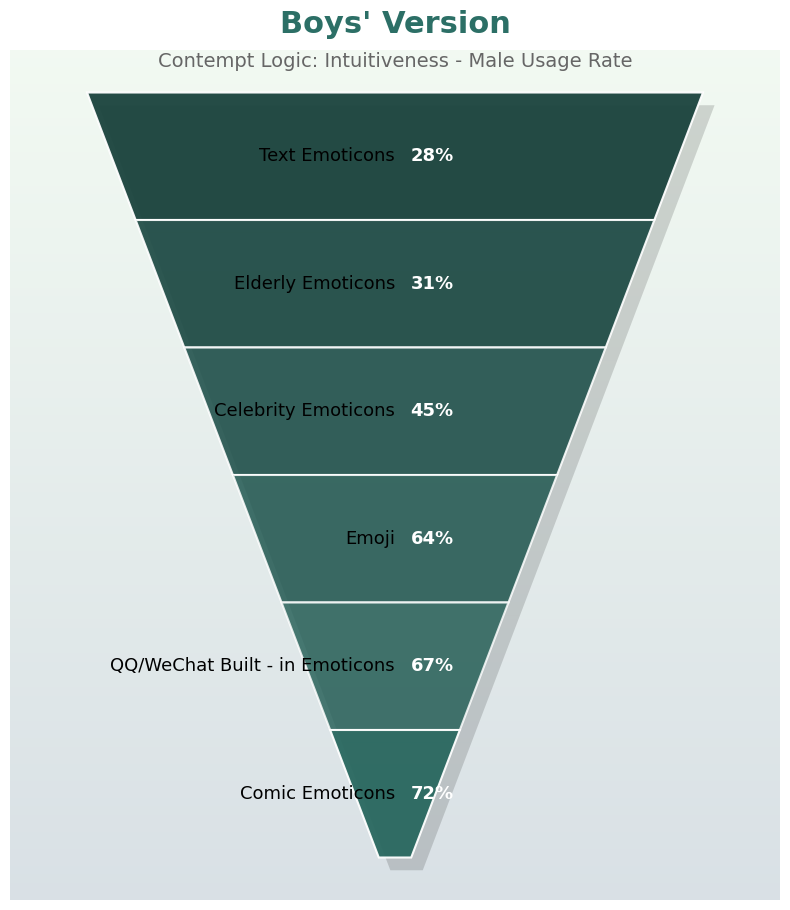

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# Labels and data (corresponding to the boys' version of the contempt logic: Intuitiveness - Male usage rate data)
labels = [
    "Text Emoticons", "Elderly Emoticons", "Celebrity Emoticons",
    "Emoji", "QQ/WeChat Built - in Emoticons", "Comic Emoticons"
]
values = [28, 31, 45, 64, 67, 72]

# Generate a gradient color scheme
def get_gradient_colors(base_color, num_layers, lightness_range=(0.6, 1.0)):
    """Generate a gradient from dark to light"""
    from matplotlib.colors import LinearSegmentedColormap
    import matplotlib.colors as mcolors

    # Convert hexadecimal color to RGB
    rgb = mcolors.hex2color(base_color)

    # Create a gradient color map
    cmap = LinearSegmentedColormap.from_list(
        f'custom_{base_color}',
        [(rgb[0]*lightness_range[0], rgb[1]*lightness_range[0], rgb[2]*lightness_range[0]),
         (rgb[0]*lightness_range[1], rgb[1]*lightness_range[1], rgb[2]*lightness_range[1])]
    )

    return [cmap(i/num_layers) for i in range(num_layers)]

# Use the green color scheme as the basis
base_color = '#2c6f66'
colors = get_gradient_colors(base_color, len(labels))

# Graph parameters
num_layers = len(labels)
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Bottom vertex coordinates
bottom_x = 0.5
bottom_y = 0.05

# Top width (the upper side of the entire inverted triangle)
top_left = (0.1, 0.95)
top_right = (0.9, 0.95)

# Height of each layer (evenly divided)
layer_height = (top_left[1] - bottom_y) / num_layers

# Draw the background gradient
gradient_bg = np.zeros((100, 100, 3))
for i in range(100):
    for j in range(100):
        y_norm = i / 100
        # Background color changes from light green to lighter green
        gradient_bg[i, j] = [0.95 - y_norm*0.1, 0.98 - y_norm*0.1, 0.95 - y_norm*0.05]
ax.imshow(gradient_bg, extent=[0, 1, 0, 1], aspect='auto', zorder=0)

# Add shadow effect
shadow_offset = 0.015
for i in range(num_layers):
    # Top y and bottom y
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # Calculate the x - coordinates of the left and right boundaries of the triangle at the corresponding height
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # Construct the shadow shape
    shadow_points = [
        (x_left_top + shadow_offset, y_top - shadow_offset),
        (x_right_top + shadow_offset, y_top - shadow_offset),
        (x_right_bottom + shadow_offset, y_bottom - shadow_offset),
        (x_left_bottom + shadow_offset, y_bottom - shadow_offset)
    ]
    shadow = Polygon(shadow_points, closed=True, facecolor='black', alpha=0.15, zorder=i+1)
    ax.add_patch(shadow)

# Draw the main chart
for i in range(num_layers):
    # Top y and bottom y
    y_top = top_left[1] - i * layer_height
    y_bottom = top_left[1] - (i + 1) * layer_height

    # Calculate the x - coordinates of the left and right boundaries of the triangle at the corresponding height
    x_left_top = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_top) / top_left[1]
    x_right_top = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_top) / top_right[1]
    x_left_bottom = top_left[0] + (bottom_x - top_left[0]) * (top_left[1] - y_bottom) / top_left[1]
    x_right_bottom = top_right[0] - (top_right[0] - bottom_x) * (top_right[1] - y_bottom) / top_right[1]

    # Construct the trapezoid/triangular strip shape
    points = [
        (x_left_top, y_top),
        (x_right_top, y_top),
        (x_right_bottom, y_bottom),
        (x_left_bottom, y_bottom)
    ]

    # Add a slight transparency change to make the bottom more obvious
    alpha = 0.95 - i * 0.03 if i < num_layers - 1 else 0.95
    tri = Polygon(points, closed=True, facecolor=colors[i], edgecolor='white', linewidth=1.5, alpha=alpha, zorder=i+2)
    ax.add_patch(tri)

    # Write text in the middle of each layer
    y_text = (y_top + y_bottom) / 2
    ax.text(0.5, y_text, f"{labels[i]}",
            color='black', ha='right', va='center', fontsize=13, fontweight='medium',
            transform=ax.transAxes, zorder=10)

    # Add percentage labels
    ax.text(0.52, y_text, f"{values[i]}%",
            color='white', ha='left', va='center', fontsize=13, fontweight='bold',
            transform=ax.transAxes, zorder=10)

# Add new title - related text, adjust the title and subtitle content according to the boys' version requirements
plt.text(0.5, 1.02, "Boys' Version", ha='center', fontsize=22, weight='bold', color=base_color, transform=ax.transAxes)
plt.text(0.5, 0.98, "Contempt Logic: Intuitiveness - Male Usage Rate", ha='center', fontsize=14, color='#666666', transform=ax.transAxes)

# Adjust the layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05)
plt.show()

# 文件: chart_24_3.py

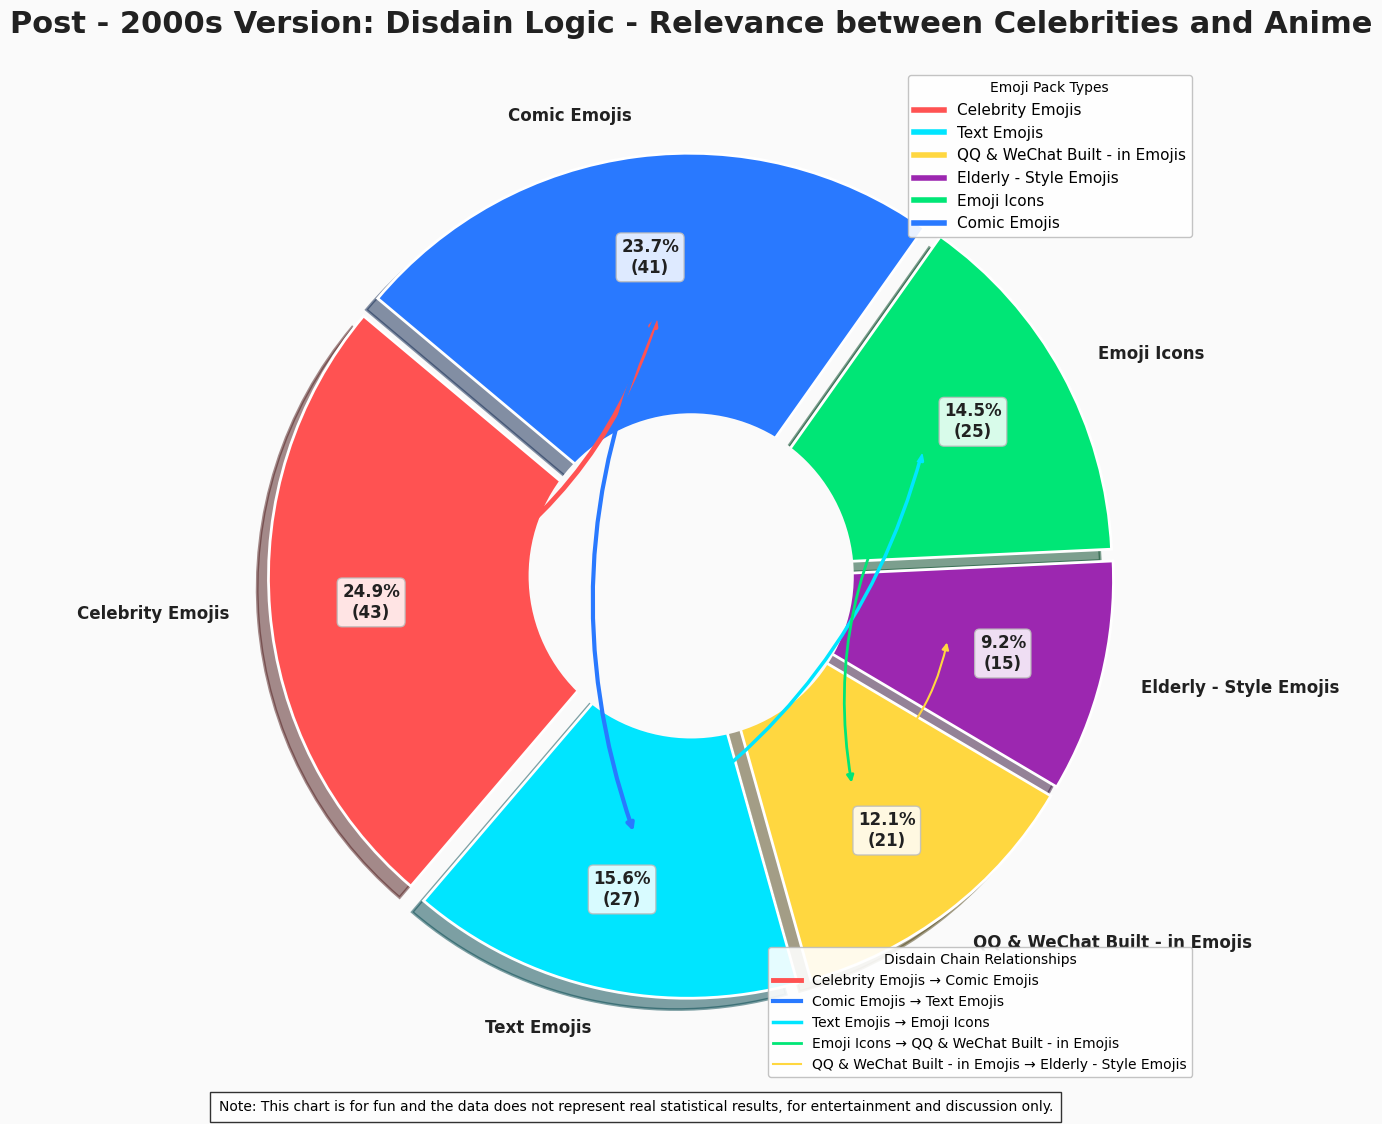

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Emoji pack color scheme (strictly corresponding to types)
color_map = {
    'Celebrity Emojis': '#FF5252',
    'Text Emojis': '#00E5FF',
    'QQ & WeChat Built - in Emojis': '#FFD740',
    'Elderly - Style Emojis': '#9C27B0',
    'Emoji Icons': '#00E676',
    'Comic Emojis': '#2979FF',
}

# Data definition (keep the original logic)
categories = ['Celebrity Emojis', 'Text Emojis', 'QQ & WeChat Built - in Emojis', 
              'Elderly - Style Emojis', 'Emoji Icons', 'Comic Emojis']
percentages = [43, 27, 21, 16, 25, 41]

#鄙视链关系（明确类型对应，方便颜色映射）
# Disdain chain relationships (clearly correspond to types for easy color mapping)
connections = [
    ('Celebrity Emojis', 'Comic Emojis', 3.5),   # Celebrity → Comic
    ('Comic Emojis', 'Text Emojis', 3),    # Comic → Text
    ('Text Emojis', 'Emoji Icons', 2.5),       # Text → Emoji
    ('Emoji Icons', 'QQ & WeChat Built - in Emojis', 2),    # Emoji → QQ
    ('QQ & WeChat Built - in Emojis', 'Elderly - Style Emojis', 1.5),  # QQ → Elderly
]

# Create a canvas and basic settings
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# Draw a pie chart (enhance shadow and border)
wedges, texts, autotexts = ax.pie(
    percentages, 
    labels=categories, 
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(percentages) / 100)})',
    colors=[color_map[c] for c in categories],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# Center white mask (enhance the sense of hierarchy)
center_circle = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(center_circle)

# Optimize the style of percentage labels (with a white background box)
for a in autotexts:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# Set the title
ax.set_title('Post - 2000s Version: Disdain Logic - Relevance between Celebrities and Anime', 
             fontsize=22, 
             fontweight='bold', 
             color='#212121',
             pad=25)

# Draw disdain chain arrows (the color strictly corresponds to the main color of the emoji pack)
for start_cat, end_cat, weight in connections:
    # Find the angle of the corresponding sector
    start_wedge = [w for w, l in zip(wedges, categories) if l == start_cat][0]
    end_wedge = [w for w, l in zip(wedges, categories) if l == end_cat][0]
    
    start_angle = (start_wedge.theta2 + start_wedge.theta1) / 2
    end_angle = (end_wedge.theta2 + end_wedge.theta1) / 2
    
    # Calculate coordinates (unified radius to avoid confusion)
    radius = 0.65
    start_x = np.cos(np.radians(start_angle)) * radius
    start_y = np.sin(np.radians(start_angle)) * radius
    end_x = np.cos(np.radians(end_angle)) * radius
    end_y = np.sin(np.radians(end_angle)) * radius
    
    # Draw an arrow (single color, consistent with the color of the starting emoji pack)
    ax.annotate(
        '', 
        xy=(end_x, end_y), 
        xytext=(start_x, start_y),
        arrowprops=dict(
            arrowstyle='-|>', 
            color=color_map[start_cat],  # Use the color of the starting type
            lw=weight,
            connectionstyle="arc3,rad=0.2"
        )
    )

# Build a legend (divided into two groups: types + relationships)
legend_type = [
    Line2D([0], [0], color=color_map[c], lw=4, label=c) 
    for c in categories
]

legend_arrow = [
    Line2D([0], [0], color=color_map[start], lw=weight, label=f'{start} → {end}') 
    for start, end, weight in connections
]

# Combine the legends (types first, then relationships)
legend1 = ax.legend(
    handles=legend_type, 
    loc='upper right', 
    title="Emoji Pack Types", 
    fontsize=11, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)
ax.add_artist(legend1)

ax.legend(
    handles=legend_arrow, 
    loc='lower right', 
    title="Disdain Chain Relationships", 
    fontsize=10, 
    frameon=True,
    framealpha=0.9, 
    facecolor='white', 
    edgecolor='#BDBDBD'
)

# Bottom note
plt.figtext(
    0.15, 0.02, 
    "Note: This chart is for fun and the data does not represent real statistical results, for entertainment and discussion only.", 
    ha="left", 
    fontsize=10, 
    bbox={"facecolor":"white", "alpha":0.8, "pad":6}
)

# Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 文件: chart_24_4.py

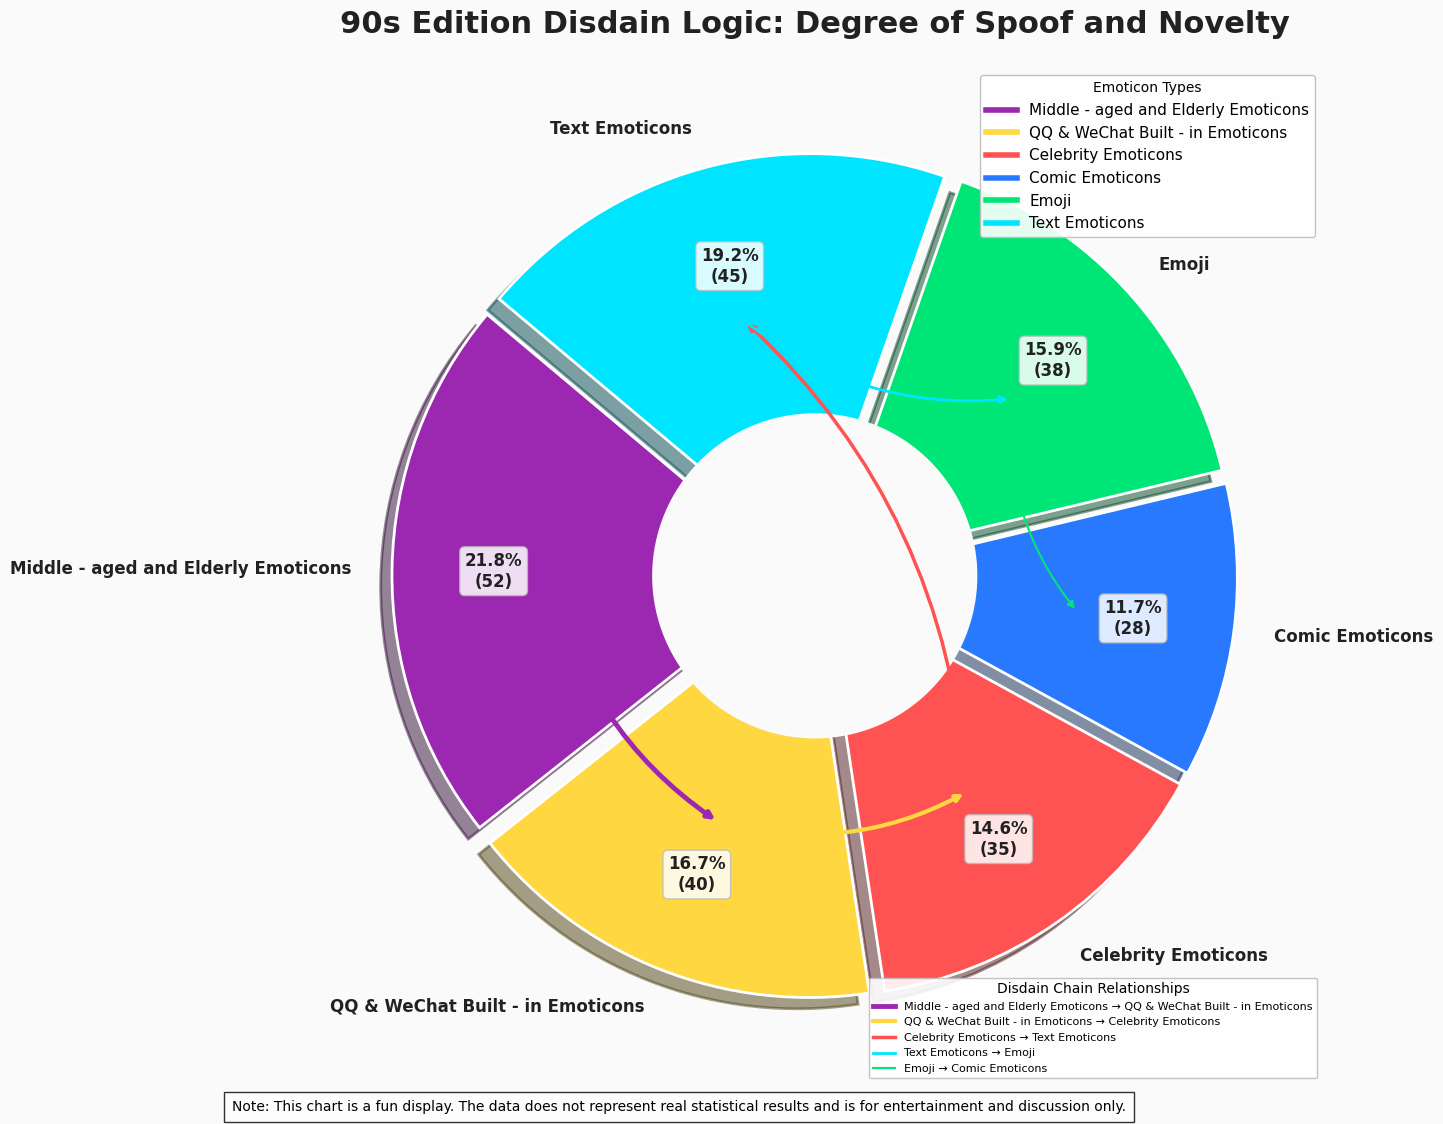

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Emoticon color scheme (strictly corresponding to types)
color_map = {
    'Celebrity Emoticons': '#FF5252',
    'Text Emoticons': '#00E5FF',
    'QQ & WeChat Built - in Emoticons': '#FFD740',
    'Middle - aged and Elderly Emoticons': '#9C27B0',
    'Emoji': '#00E676',
    'Comic Emoticons': '#2979FF',
}

# Data definition (keep the original logic)
categories = ['Middle - aged and Elderly Emoticons', 'QQ & WeChat Built - in Emoticons', 'Celebrity Emoticons',
              'Comic Emoticons', 'Emoji', 'Text Emoticons']
percentages = [52, 40, 35, 28, 38, 46]

# Disdain chain relationships (clearly corresponding to types for color mapping)
connections = [
    ('Middle - aged and Elderly Emoticons', 'QQ & WeChat Built - in Emoticons', 3.5),  # Middle - aged → QQ & WeChat
    ('QQ & WeChat Built - in Emoticons', 'Celebrity Emoticons', 3),  # QQ & WeChat → Celebrity
    ('Celebrity Emoticons', 'Text Emoticons', 2.5),  # Celebrity → Text
    ('Text Emoticons', 'Emoji', 2),  # Text → Emoji
    ('Emoji', 'Comic Emoticons', 1.5),  # Emoji → Comic
]

# Create a canvas and basic settings
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# Draw a pie chart (enhance shadow and border)
wedges, texts, autotexts = ax.pie(
    percentages,
    labels=categories,
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(percentages) / 100)})',
    colors=[color_map[c] for c in categories],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# Center white mask (enhance the sense of hierarchy)
center_circle = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(center_circle)

# Optimize the style of percentage labels (with a white background box)
for a in autotexts:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# Set the title
ax.set_title('90s Edition Disdain Logic: Degree of Spoof and Novelty',
             fontsize=22,
             fontweight='bold',
             color='#212121',
             pad=25)

# Draw disdain chain arrows (colors strictly correspond to the main color of emoticons)
for start_cat, end_cat, weight in connections:
    # Find the angle of the corresponding sector
    start_wedge = [w for w, l in zip(wedges, categories) if l == start_cat][0]
    end_wedge = [w for w, l in zip(wedges, categories) if l == end_cat][0]

    start_angle = (start_wedge.theta2 + start_wedge.theta1) / 2
    end_angle = (end_wedge.theta2 + end_wedge.theta1) / 2

    # Calculate coordinates (unify the radius to avoid confusion)
    radius = 0.65
    start_x = np.cos(np.radians(start_angle)) * radius
    start_y = np.sin(np.radians(start_angle)) * radius
    end_x = np.cos(np.radians(end_angle)) * radius
    end_y = np.sin(np.radians(end_angle)) * radius

    # Draw an arrow (single color, consistent with the color of the starting emoticon)
    ax.annotate(
        '',
        xy=(end_x, end_y),
        xytext=(start_x, start_y),
        arrowprops=dict(
            arrowstyle='-|>',
            color=color_map[start_cat],  # Use the color of the starting type
            lw=weight,
            connectionstyle="arc3,rad=0.2"
        )
    )

# Build the legend (divided into two groups: types + relationships)
legend_type = [
    Line2D([0], [0], color=color_map[c], lw=4, label=c)
    for c in categories
]

legend_arrow = [
    Line2D([0], [0], color=color_map[start], lw=weight, label=f'{start} → {end}')
    for start, end, weight in connections
]

# Combine the legends (types first, then relationships)
legend1 = ax.legend(
    handles=legend_type,
    loc='upper right',
    title="Emoticon Types",
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#BDBDBD'
)
ax.add_artist(legend1)

ax.legend(
    handles=legend_arrow,
    loc='lower right',
    title="Disdain Chain Relationships",
    fontsize=8,
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#BDBDBD'
)

# Bottom note
plt.figtext(
    0.15, 0.02,
    "Note: This chart is a fun display. The data does not represent real statistical results and is for entertainment and discussion only.",
    ha="left",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.8, "pad": 6}
)

# Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 文件: chart_24_5.py

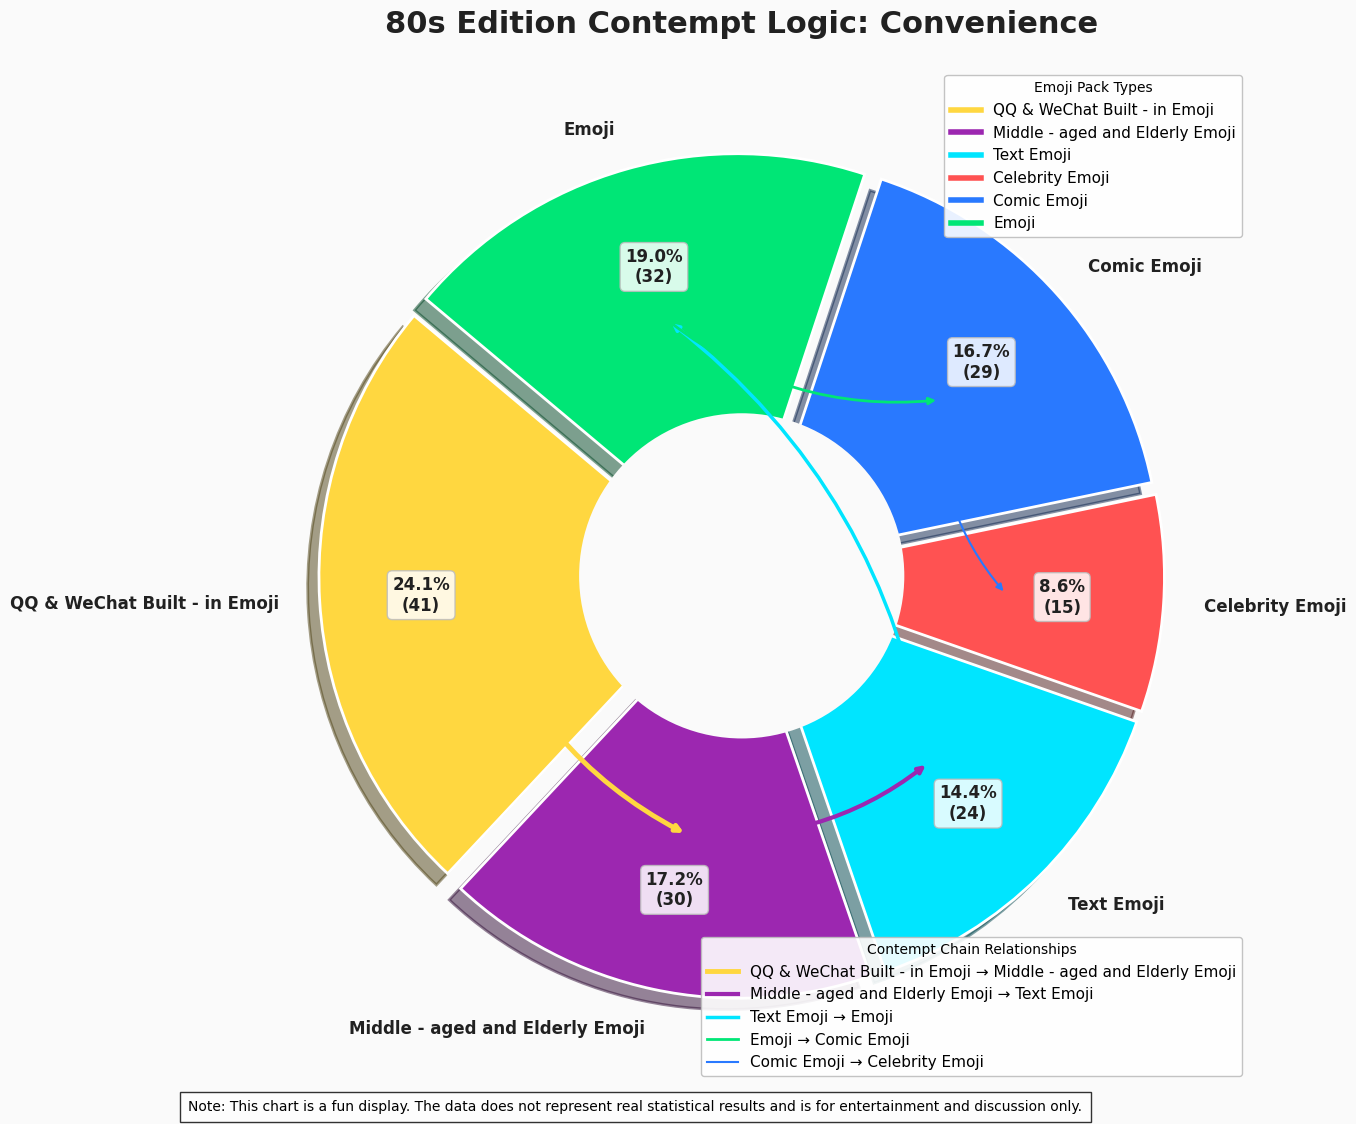

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Emoji pack color scheme (strictly corresponding to types)
color_map = {
    'Celebrity Emoji': '#FF5252',
    'Text Emoji': '#00E5FF',
    'QQ & WeChat Built - in Emoji': '#FFD740',
    'Middle - aged and Elderly Emoji': '#9C27B0',
    'Emoji': '#00E676',
    'Comic Emoji': '#2979FF',
}

# Data definition (keep the original logic)
categories = ['QQ & WeChat Built - in Emoji', 'Middle - aged and Elderly Emoji', 'Text Emoji',
              'Celebrity Emoji', 'Comic Emoji', 'Emoji']
percentages = [42, 30, 25, 15, 29, 33]

# Contempt chain relationships (clearly corresponding to types for color mapping)
connections = [
    ('QQ & WeChat Built - in Emoji', 'Middle - aged and Elderly Emoji', 3.5),  # QQ & WeChat → Middle - aged and Elderly
    ('Middle - aged and Elderly Emoji', 'Text Emoji', 3),       # Middle - aged and Elderly → Text
    ('Text Emoji', 'Emoji', 2.5),           # Text → Emoji
    ('Emoji', 'Comic Emoji', 2),            # Emoji → Comic
    ('Comic Emoji', 'Celebrity Emoji', 1.5),        # Comic → Celebrity
]

# Create the canvas and basic settings
fig, ax = plt.subplots(figsize=(14, 12), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, linestyle='--', alpha=0.3, color='#EEEEEE')

# Draw the pie chart (enhance shadow and border)
wedges, texts, autotexts = ax.pie(
    percentages,
    labels=categories,
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(percentages) / 100)})',
    colors=[color_map[c] for c in categories],
    startangle=140,
    pctdistance=0.75,
    explode=[0.04] * 6,
    shadow=True,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 12, 'weight': 'bold', 'color': '#212121'}
)

# Center white mask (enhance the sense of hierarchy)
center_circle = plt.Circle((0, 0), 0.4, color='#FAFAFA', linewidth=0, zorder=1)
ax.add_artist(center_circle)

# Optimize the style of percentage labels (with a white background box)
for a in autotexts:
    a.set_bbox(dict(boxstyle="round,pad=0.3", fc="white", ec="#BDBDBD", alpha=0.85))

# Set the title
ax.set_title('80s Edition Contempt Logic: Convenience',
             fontsize=22,
             fontweight='bold',
             color='#212121',
             pad=25)

# Draw the contempt chain arrows (colors strictly correspond to the main color of the emoji pack)
for start_cat, end_cat, weight in connections:
    # Find the angle of the corresponding sector
    start_wedge = [w for w, l in zip(wedges, categories) if l == start_cat][0]
    end_wedge = [w for w, l in zip(wedges, categories) if l == end_cat][0]

    start_angle = (start_wedge.theta2 + start_wedge.theta1) / 2
    end_angle = (end_wedge.theta2 + end_wedge.theta1) / 2

    # Calculate the coordinates (unified radius to avoid confusion)
    radius = 0.65
    start_x = np.cos(np.radians(start_angle)) * radius
    start_y = np.sin(np.radians(start_angle)) * radius
    end_x = np.cos(np.radians(end_angle)) * radius
    end_y = np.sin(np.radians(end_angle)) * radius

    # Draw the arrow (single - color, consistent with the color of the starting emoji pack)
    ax.annotate(
        '',
        xy=(end_x, end_y),
        xytext=(start_x, start_y),
        arrowprops=dict(
            arrowstyle='-|>',
            color=color_map[start_cat],  # Use the color of the starting type
            lw=weight,
            connectionstyle="arc3,rad=0.2"
        )
    )

# Build the legend (divided into two groups: types + relationships)
legend_type = [
    Line2D([0], [0], color=color_map[c], lw=4, label=c)
    for c in categories
]

legend_arrow = [
    Line2D([0], [0], color=color_map[start], lw=weight, label=f'{start} → {end}')
    for start, end, weight in connections
]

# Combine the legends (types first, then relationships)
legend1 = ax.legend(
    handles=legend_type,
    loc='upper right',
    title="Emoji Pack Types",
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#BDBDBD'
)
ax.add_artist(legend1)

ax.legend(
    handles=legend_arrow,
    loc='lower right',
    title="Contempt Chain Relationships",
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#BDBDBD'
)

# Bottom annotation
plt.figtext(
    0.15, 0.02,
    "Note: This chart is a fun display. The data does not represent real statistical results and is for entertainment and discussion only.",
    ha="left",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.8, "pad": 6}
)

# Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()